<a href="https://colab.research.google.com/github/Shirodevops/Hands-On-Large-Language-Models/blob/main/courses/udacity_intro_to_tensorflow_for_deep_learning/l01c01_introduction_to_colab_and_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2018 The TensorFlow Authors.

        PC1       PC2 Customer
0  1.971065  0.246204       C1
1  1.517535  0.248562       C2
2  2.424596  0.243846       C3
3 -1.949016  0.178024       C4
4 -1.495486  0.175667       C5
5 -1.948266 -0.151391       C6
6  0.627373 -0.373765       C7
7  0.173842 -0.371407       C8
8  1.080903 -0.376123       C9
9 -2.402546  0.180382      C10


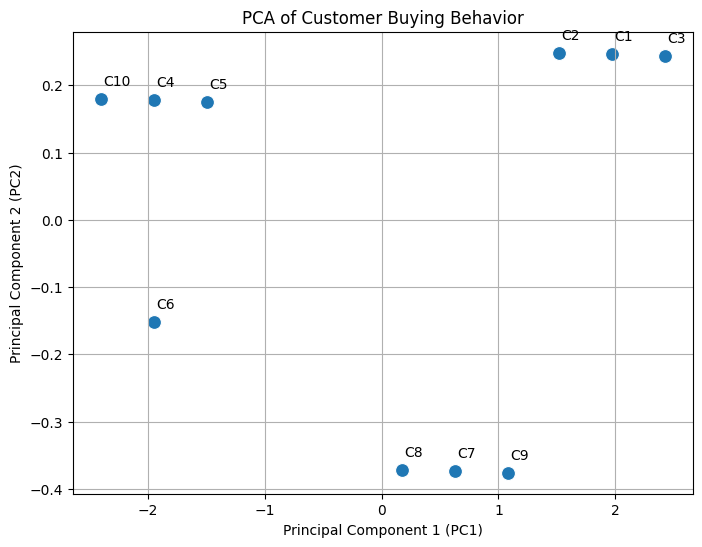

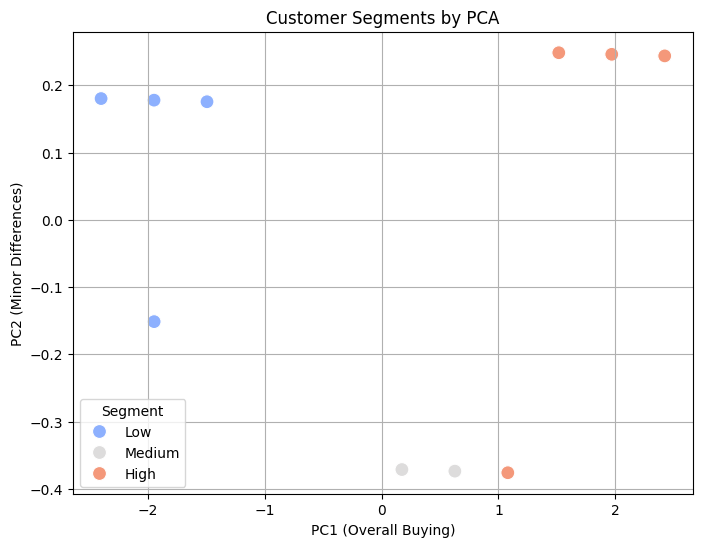

In [1]:
from numpy.ma.core import shape
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


data = {
    "Product_A": [10,9,11,2,3,2,8,7,9,1],
    "Product_B": [12,11,13,3,4,2,7,6,8,2],
    "Product_C": [11,10,12,2,3,3,9,8,10,1]
}

df = pd.DataFrame(data)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

#cov_matrix = np.cov(X_scaled.T)

pca = PCA(n_components=2) #2D Plots
X_pca = pca.fit_transform(X_scaled)


#Convert to dataframe for plotting
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca["Customer"] = [f"C{i+1}" for i in range(len(df))]
print(df_pca)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca , s=100) # hue='Customer', palette='viridis')

# Add customer labels
for i in range(df_pca.shape[0]):
      plt.text(df_pca["PC1"][i]+0.02, df_pca["PC2"][i]+0.02, df_pca["Customer"][i])


plt.title("PCA of Customer Buying Behavior")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.grid(True)
plt.show()



df_pca["Segment"] = pd.cut(df_pca["PC1"], bins=3, labels=["Low", "Medium", "High"])

plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="Segment", palette="coolwarm", data=df_pca, s=100)
plt.title("Customer Segments by PCA")
plt.xlabel("PC1 (Overall Buying)")
plt.ylabel("PC2 (Minor Differences)")
plt.grid(True)
plt.show()






## **Introduction to Colab and Python**

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/examples/blob/master/courses/udacity_intro_to_tensorflow_for_deep_learning/l01c01_introduction_to_colab_and_python.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/examples/blob/master/courses/udacity_intro_to_tensorflow_for_deep_learning/l01c01_introduction_to_colab_and_python.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

Welcome to this Colab where you will get a quick introduction to the Python programming language and the environment used for the course's exercises: Colab.

Colab is a Python development environment that runs in the browser using Google Cloud.

For example, to print "Hello World", just hover the mouse over [ ] and press the play button to the upper left. Or press shift-enter to execute.

In [2]:
print("Hello World")

Hello World


## Functions, Conditionals, and Iteration
Let's create a Python function, and call it from a loop.

In [3]:
def HelloWorldXY(x, y):
  if (x < 10):
    print("Hello World, x was < 10")
  elif (x < 20):
    print("Hello World, x was >= 10 but < 20")
  else:
    print("Hello World, x was >= 20")
  return x + y

for i in range(8, 25, 5):  # i=8, 13, 18, 23 (start, stop, step)
  print("--- Now running with i: {}".format(i))
  r = HelloWorldXY(i,i)
  print("Result from HelloWorld: {}".format(r))

--- Now running with i: 8
Hello World, x was < 10
Result from HelloWorld: 16
--- Now running with i: 13
Hello World, x was >= 10 but < 20
Result from HelloWorld: 26
--- Now running with i: 18
Hello World, x was >= 10 but < 20
Result from HelloWorld: 36
--- Now running with i: 23
Hello World, x was >= 20
Result from HelloWorld: 46


In [4]:
print(HelloWorldXY(1,2))

Hello World, x was < 10
3


Easy, right?

If you want a loop starting at 0 to 2 (exclusive) you could do any of the following

In [5]:
print("Iterate over the items. `range(2)` is like a list [0,1].")
for i in range(2):
  print(i)

print("Iterate over an actual list.")
for i in [0,1]:
  print(i)

print("While works")
i = 0
while i < 2:
  print(i)
  i += 1

Iterate over the items. `range(2)` is like a list [0,1].
0
1
Iterate over an actual list.
0
1
While works
0
1


In [6]:
print("Python supports standard key words like continue and break")
while True:
  print("Entered while")
  break

Python supports standard key words like continue and break
Entered while


## Numpy and lists
Python has lists built into the language.
However, we will use a library called numpy for this.
Numpy gives you lots of support functions that are useful when doing Machine Learning.

Here, you will also see an import statement. This statement makes the entire numpy package available and we can access those symbols using the abbreviated 'np' syntax.

In [7]:
import numpy as np  # Make numpy available using np.

# Create a numpy array, and append an element
a = np.array(["Hello", "World"])
a = np.append(a, "!")
print("Current array: {}".format(a))
print("Printing each element")
for i in a:
  print(i)

print("\nPrinting each element and their index")
for i,e in enumerate(a):
  print("Index: {}, was: {}".format(i, e))

Current array: ['Hello' 'World' '!']
Printing each element
Hello
World
!

Printing each element and their index
Index: 0, was: Hello
Index: 1, was: World
Index: 2, was: !


In [8]:
print("\nShowing some basic math on arrays")
b = np.array([0,1,4,3,2])
print("Max: {}".format(np.max(b)))
print("Average: {}".format(np.average(b)))
print("Max index: {}".format(np.argmax(b)))


Showing some basic math on arrays
Max: 4
Average: 2.0
Max index: 2


In [9]:
print("\nYou can print the type of anything")
print("Type of b: {}, type of b[0]: {}".format(type(b), type(b[0])))


You can print the type of anything
Type of b: <class 'numpy.ndarray'>, type of b[0]: <class 'numpy.int64'>


In [10]:
print("\nUse numpy to create a [3,3] dimension array with random number")
c = np.random.rand(3, 3)
print(c)


Use numpy to create a [3,3] dimension array with random number
[[0.64712976 0.07105352 0.94492569]
 [0.81026855 0.48573934 0.79736769]
 [0.14477371 0.01192046 0.88862579]]


In [11]:
print("\nYou can print the dimensions of arrays")
print("Shape of a: {}".format(a.shape))
print("Shape of b: {}".format(b.shape))
print("Shape of c: {}".format(c.shape))
print("...Observe, Python uses both [0,1,2] and (0,1,2) to specify lists")


You can print the dimensions of arrays
Shape of a: (3,)
Shape of b: (5,)
Shape of c: (3, 3)
...Observe, Python uses both [0,1,2] and (0,1,2) to specify lists


## Colab Specifics

Colab is a virtual machine you can access directly. To run commands at the VM's terminal, prefix the line with an exclamation point (!).


In [12]:
print("\nDoing $ls on filesystem")
!ls -l
!pwd


Doing $ls on filesystem
total 4
drwxr-xr-x 1 root root 4096 Dec  9 14:42 sample_data
/content


In [13]:
print("Install numpy")  # Just for test, numpy is actually preinstalled in all Colab instances
!pip install numpy

Install numpy


**Exercise**

Create a code cell underneath this text cell and add code to:


*   List the path of the current directory (pwd)
* Go to / (cd) and list the content (ls -l)

In [14]:
!pwd
!cd /
!ls -l
print("Hello")

/content
total 4
drwxr-xr-x 1 root root 4096 Dec  9 14:42 sample_data
Hello


All usage of Colab in this course is completely free or charge. Even GPU usage is provided free of charge for some hours of usage every day.

**Using GPUs**
* Many of the exercises in the course executes more quickly by using GPU runtime: Runtime | Change runtime type | Hardware accelerator | GPU

**Some final words on Colab**
*   You execute each cell in order, you can edit & re-execute cells if you want
*   Sometimes, this could have unintended consequences. For example, if you add a dimension to an array and execute the cell multiple times, then the cells after may not work. If you encounter problem reset your environment:
  *   Runtime -> Restart runtime... Resets your Python shell
  *   Runtime -> Restart all runtimes... Will reset the Colab image, and get you back to a 100% clean environment
* You can also clear the output in the Colab by doing: Edit -> Clear all outputs
* Colabs in this course are loaded from GitHub. Save to your Google Drive if you want a copy with your code/output: File -> Save a copy in Drive...

**Learn More**
*   Check out [this](https://www.youtube.com/watch?v=inN8seMm7UI&list=PLQY2H8rRoyvwLbzbnKJ59NkZvQAW9wLbx&index=3) episode of #CodingTensorFlow, and don't forget to subscribe to the YouTube channel ;)
